### Overview

Plotting of:
- Subtype-level boxplots of normalization count global distribution
- Gene-level distribution across subtypes for specific genes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from pydeseq2.preprocessing import deseq2_norm_fit, deseq2_norm_transform
from sklearn.decomposition import PCA
import random

#### 1. Import and prepare raw count datasets

In [2]:
# import PAM50 genes
pam50 = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/pam50gene_list_csv.csv", header=0)

In [3]:
# import raw count files
train = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/SCANB_GSE202203/scanb_hiseq_train_test_sets/train_test_80_20/SCANB_HiSeq_pam50gene_raw_counts_subtype_train_80.csv", 
                          header=0, index_col=0)
scanb_hiseq_test = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/SCANB_GSE202203/scanb_hiseq_train_test_sets/train_test_80_20/SCANB_HiSeq_pam50gene_raw_counts_subtype_test_20.csv", 
                          header=0, index_col=0)
scanb_nextseq_test = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/SCANB_GSE202203/scanb_cleaned_data/pam50genes_raw_counts_subtype_scanb_nextseq.csv", 
                          header=0, index_col=0)
tcga_test = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/TCGA_BRCA/tcga_brca_cleaned_data/pam50genes_raw_counts_subtype_tcga_brca.csv", 
                       header=0, index_col=0)

In [4]:
# check dimension
print(train.shape)
print(scanb_hiseq_test.shape)
print(scanb_nextseq_test.shape)
print(tcga_test.shape)

(2204, 52)
(551, 52)
(276, 51)
(1031, 51)


In [5]:
# check whether the first 50 column names (PAM50 gene ensembl IDs) match
print(train.columns[0:50].equals(scanb_hiseq_test.columns[0:50]))
print(train.columns[0:50].equals(scanb_nextseq_test.columns[0:50]))
print(train.columns[0:50].equals(tcga_test.columns[0:50]))

True
True
True


In [6]:
# check whether the ensemble id column order match with that of in the pam50 df
train.columns[0:50].tolist() == pam50['ensembl_gene_id'].tolist()

True

In [7]:
# extract counts
train_counts = train.iloc[:, 0:50]
scanb_hiseq_test_counts = scanb_hiseq_test.iloc[:, 0:50]
scanb_nextseq_test_counts = scanb_nextseq_test.iloc[:, 0:50]
tcga_test_counts = tcga_test.iloc[:, 0:50]

In [8]:
# rename columns
train_counts.columns = pam50['new_gene_symbol'].tolist()
scanb_hiseq_test_counts.columns = pam50['new_gene_symbol'].tolist()
scanb_nextseq_test_counts.columns = pam50['new_gene_symbol'].tolist()
tcga_test_counts.columns = pam50['new_gene_symbol'].tolist()

#### 2. Normalize raw counts using cross-sample normalization pipeline
##### PyDESeq'2 median of ratios --> Log2 transformation --> Z-score standardization

In [9]:
# deseq normalize the train set
logMeans_train, filteredGenes_train = deseq2_norm_fit(train_counts)
train_deseq2 = deseq2_norm_transform(train_counts, logMeans_train, filteredGenes_train)[0]
train_deseq2.shape

(2204, 50)

In [10]:
# deseq normalize the test sets using the train set's normalization factors
scanb_hiseq_test_deseq2 = deseq2_norm_transform(scanb_hiseq_test_counts, logMeans_train, filteredGenes_train)[0]
scanb_nextseq_test_deseq2 = deseq2_norm_transform(scanb_nextseq_test_counts, logMeans_train, filteredGenes_train)[0]
tcga_test_deseq2 = deseq2_norm_transform(tcga_test_counts, logMeans_train, filteredGenes_train)[0]

print(scanb_hiseq_test_deseq2.shape)
print(scanb_nextseq_test_deseq2.shape)
print(tcga_test_deseq2.shape)

(551, 50)
(276, 50)
(1031, 50)


In [11]:
# log2 transform the counts
train_log2 = np.log2(train_deseq2 + 1)
scanb_hiseq_test_log2 = np.log2(scanb_hiseq_test_deseq2 + 1)
scanb_nextseq_test_log2 = np.log2(scanb_nextseq_test_deseq2 + 1)
tcga_test_log2 = np.log2(tcga_test_deseq2 + 1)

In [12]:
# standardize the log2 transformed counts of the train set
scaler = StandardScaler()
train_standardized = scaler.fit_transform(train_log2)
train_standardized = pd.DataFrame(train_standardized, index=train_log2.index, columns=train_log2.columns)
train_standardized.shape

(2204, 50)

In [13]:
# standardize the log2 transformed counts of the test sets using the train set-fitted scaler
scanb_hiseq_test_standardized = scaler.transform(scanb_hiseq_test_log2)
scanb_nextseq_test_standardized = scaler.transform(scanb_nextseq_test_log2)
tcga_test_standardized = scaler.transform(tcga_test_log2)

scanb_hiseq_test_standardized = pd.DataFrame(scanb_hiseq_test_standardized, index=scanb_hiseq_test_log2.index, columns=scanb_hiseq_test_log2.columns)
scanb_nextseq_test_standardized = pd.DataFrame(scanb_nextseq_test_standardized, index=scanb_nextseq_test_log2.index, columns=scanb_nextseq_test_log2.columns)
tcga_test_standardized = pd.DataFrame(tcga_test_standardized, index=tcga_test_log2.index, columns=tcga_test_log2.columns)

#### 3. Prepare the normalized raw count datasets for visualization

In [14]:
# merge standardized counts with subtypes
train_standardized_subtype_dataset = train_standardized.join(train.loc[:, ['subtype']])
scanb_hiseq_test_standardized_subtype_dataset = scanb_hiseq_test_standardized.join(scanb_hiseq_test.loc[:, ['subtype']])
scanb_nextseq_test_standardized_subtype_dataset = scanb_nextseq_test_standardized.join(scanb_nextseq_test.loc[:, ['subtype']])
tcga_test_standardized_subtype_dataset = tcga_test_standardized.join(tcga_test.loc[:, ['subtype']])

In [15]:
# add dataset column to standardized subtype dataset
train_standardized_subtype_dataset['dataset'] = 'SCAN-B HiSeq Train'
scanb_hiseq_test_standardized_subtype_dataset['dataset'] = 'SCAN-B HiSeq Test'
scanb_nextseq_test_standardized_subtype_dataset['dataset'] = 'SCAN-B NextSeq Test'
tcga_test_standardized_subtype_dataset['dataset'] = 'TCGA-BRCA Test'

In [16]:
# merge the standardized datasets
merged_standardized_subtype_dataset = pd.concat([train_standardized_subtype_dataset, scanb_hiseq_test_standardized_subtype_dataset, 
                                    scanb_nextseq_test_standardized_subtype_dataset, tcga_test_standardized_subtype_dataset],
                                   axis=0)

In [17]:
# replace Her2 by HER2
merged_standardized_subtype_dataset['subtype'] = merged_standardized_subtype_dataset['subtype'].replace({'Her2': 'HER2'})

In [18]:
# extract gene columns
gene_columns = merged_standardized_subtype_dataset.columns[:-2]

# reshape from wide to long format
merged_standardized_subtype_dataset_long = merged_standardized_subtype_dataset.melt(id_vars=['subtype', 'dataset'], value_vars=gene_columns, var_name='gene', value_name='std_counts')

#### 4. Compare global normalized count distribution (all genes pooled) across all datasets for each subtype

#### 4.1 Mann-Whitney U statistical test to assess global distribution differences in terms of central tendency

##### Across all datasets for Basal

In [19]:
# extract values for basal
basal_hiseq_train = merged_standardized_subtype_dataset_long.loc[(merged_standardized_subtype_dataset_long['subtype']=='Basal') 
& (merged_standardized_subtype_dataset_long['dataset'] == 'SCAN-B HiSeq Train'), 'std_counts']

basal_hiseq_test = merged_standardized_subtype_dataset_long.loc[(merged_standardized_subtype_dataset_long['subtype']=='Basal') 
& (merged_standardized_subtype_dataset_long['dataset'] == 'SCAN-B HiSeq Test'), 'std_counts']

basal_nextseq_test = merged_standardized_subtype_dataset_long.loc[(merged_standardized_subtype_dataset_long['subtype']=='Basal') 
& (merged_standardized_subtype_dataset_long['dataset'] == 'SCAN-B NextSeq Test'), 'std_counts']

basal_tcga_test = merged_standardized_subtype_dataset_long.loc[(merged_standardized_subtype_dataset_long['subtype']=='Basal') 
& (merged_standardized_subtype_dataset_long['dataset'] == 'TCGA-BRCA Test'), 'std_counts']


In [20]:
# mann whitney test for basal
stat_basal_hiseqTrain_hiseqTest, p_value_basal_hiseqTrain_hiseqTest = stats.mannwhitneyu(basal_hiseq_train, basal_hiseq_test)
print(f"SCAN-B HiSeq Train vs SCAN-B HiSeq Test: {p_value_basal_hiseqTrain_hiseqTest}")

stat_basal_hiseqTrain_nextseqTest, p_value_basal_hiseqTrain_nextseqTest = stats.mannwhitneyu(basal_hiseq_train, basal_nextseq_test)
print(f"SCAN-B HiSeq Train vs SCAN-B NextSeq Test: {p_value_basal_hiseqTrain_nextseqTest}")

stat_basal_hiseqTrain_tcgaTest, p_value_basal_hiseqTrain_tcgaTest = stats.mannwhitneyu(basal_hiseq_train, basal_tcga_test)
print(f"SCAN-B HiSeq Train vs TCGA-BRCA Test: {p_value_basal_hiseqTrain_tcgaTest}")

SCAN-B HiSeq Train vs SCAN-B HiSeq Test: 0.3342105389912099
SCAN-B HiSeq Train vs SCAN-B NextSeq Test: 0.5430085814289318
SCAN-B HiSeq Train vs TCGA-BRCA Test: 0.8511093872913067


##### Across all datasets for HER2

In [21]:
# extract values
her2_hiseq_train = merged_standardized_subtype_dataset_long.loc[(merged_standardized_subtype_dataset_long['subtype']=='HER2') 
& (merged_standardized_subtype_dataset_long['dataset'] == 'SCAN-B HiSeq Train'), 'std_counts']

her2_hiseq_test = merged_standardized_subtype_dataset_long.loc[(merged_standardized_subtype_dataset_long['subtype']=='HER2') 
& (merged_standardized_subtype_dataset_long['dataset'] == 'SCAN-B HiSeq Test'), 'std_counts']

her2_nextseq_test = merged_standardized_subtype_dataset_long.loc[(merged_standardized_subtype_dataset_long['subtype']=='HER2') 
& (merged_standardized_subtype_dataset_long['dataset'] == 'SCAN-B NextSeq Test'), 'std_counts']

her2_tcga_test = merged_standardized_subtype_dataset_long.loc[(merged_standardized_subtype_dataset_long['subtype']=='HER2') 
& (merged_standardized_subtype_dataset_long['dataset'] == 'TCGA-BRCA Test'), 'std_counts']

In [22]:
# mann whitney test for her2
stat_her2_hiseqTrain_hiseqTest, p_value_her2_hiseqTrain_hiseqTest = stats.mannwhitneyu(her2_hiseq_train, her2_hiseq_test)
print(f"SCAN-B HiSeq Train vs SCAN-B HiSeq Test: {p_value_her2_hiseqTrain_hiseqTest}")

stat_her2_hiseqTrain_nextseqTest, p_value_her2_hiseqTrain_nextseqTest = stats.mannwhitneyu(her2_hiseq_train, her2_nextseq_test)
print(f"SCAN-B HiSeq Train vs SCAN-B NextSeq Test: {p_value_her2_hiseqTrain_nextseqTest}")

stat_her2_hiseqTrain_tcgaTest, p_value_her2_hiseqTrain_tcgaTest = stats.mannwhitneyu(her2_hiseq_train, her2_tcga_test)
print(f"SCAN-B HiSeq Train vs TCGA-BRCA Test: {p_value_her2_hiseqTrain_tcgaTest}")

SCAN-B HiSeq Train vs SCAN-B HiSeq Test: 0.9737263801780409
SCAN-B HiSeq Train vs SCAN-B NextSeq Test: 0.21118235985455258
SCAN-B HiSeq Train vs TCGA-BRCA Test: 0.21976303094295846


##### Across all datasets for LumA

In [23]:
lumA_hiseq_train = merged_standardized_subtype_dataset_long.loc[(merged_standardized_subtype_dataset_long['subtype']=='LumA') 
& (merged_standardized_subtype_dataset_long['dataset'] == 'SCAN-B HiSeq Train'), 'std_counts']

lumA_hiseq_test = merged_standardized_subtype_dataset_long.loc[(merged_standardized_subtype_dataset_long['subtype']=='LumA') 
& (merged_standardized_subtype_dataset_long['dataset'] == 'SCAN-B HiSeq Test'), 'std_counts']

lumA_nextseq_test = merged_standardized_subtype_dataset_long.loc[(merged_standardized_subtype_dataset_long['subtype']=='LumA') 
& (merged_standardized_subtype_dataset_long['dataset'] == 'SCAN-B NextSeq Test'), 'std_counts']

lumA_tcga_test = merged_standardized_subtype_dataset_long.loc[(merged_standardized_subtype_dataset_long['subtype']=='LumA') 
& (merged_standardized_subtype_dataset_long['dataset'] == 'TCGA-BRCA Test'), 'std_counts']

In [24]:
# mann whitney test for lumA
stat_lumA_hiseqTrain_hiseqTest, p_value_lumA_hiseqTrain_hiseqTest = stats.mannwhitneyu(lumA_hiseq_train, lumA_hiseq_test)
print(f"SCAN-B HiSeq Train vs SCAN-B HiSeq Test: {p_value_lumA_hiseqTrain_hiseqTest}")

stat_lumA_hiseqTrain_nextseqTest, p_value_lumA_hiseqTrain_nextseqTest = stats.mannwhitneyu(lumA_hiseq_train, lumA_nextseq_test)
print(f"SCAN-B HiSeq Train vs SCAN-B NextSeq Test: {p_value_lumA_hiseqTrain_nextseqTest}")

stat_lumA_hiseqTrain_tcgaTest, p_value_lumA_hiseqTrain_tcgaTest = stats.mannwhitneyu(lumA_hiseq_train, lumA_tcga_test)
print(f"SCAN-B HiSeq Train vs TCGA-BRCA Test: {p_value_lumA_hiseqTrain_tcgaTest}")

SCAN-B HiSeq Train vs SCAN-B HiSeq Test: 0.15036595860960045
SCAN-B HiSeq Train vs SCAN-B NextSeq Test: 0.9880906293416808
SCAN-B HiSeq Train vs TCGA-BRCA Test: 0.019379894547049407


##### Across all datasets for LumB

In [25]:
lumB_hiseq_train = merged_standardized_subtype_dataset_long.loc[(merged_standardized_subtype_dataset_long['subtype']=='LumB') 
& (merged_standardized_subtype_dataset_long['dataset'] == 'SCAN-B HiSeq Train'), 'std_counts']

lumB_hiseq_test = merged_standardized_subtype_dataset_long.loc[(merged_standardized_subtype_dataset_long['subtype']=='LumB') 
& (merged_standardized_subtype_dataset_long['dataset'] == 'SCAN-B HiSeq Test'), 'std_counts']

lumB_nextseq_test = merged_standardized_subtype_dataset_long.loc[(merged_standardized_subtype_dataset_long['subtype']=='LumB') 
& (merged_standardized_subtype_dataset_long['dataset'] == 'SCAN-B NextSeq Test'), 'std_counts']

lumB_tcga_test = merged_standardized_subtype_dataset_long.loc[(merged_standardized_subtype_dataset_long['subtype']=='LumB') 
& (merged_standardized_subtype_dataset_long['dataset'] == 'TCGA-BRCA Test'), 'std_counts']

In [26]:
# mann whitney test for lumB
stat_lumB_hiseqTrain_hiseqTest, p_value_lumB_hiseqTrain_hiseqTest = stats.mannwhitneyu(lumB_hiseq_train, lumB_hiseq_test)
print(f"SCAN-B HiSeq Train vs SCAN-B HiSeq Test: {p_value_lumB_hiseqTrain_hiseqTest}")

stat_lumB_hiseqTrain_nextseqTest, p_value_lumB_hiseqTrain_nextseqTest = stats.mannwhitneyu(lumB_hiseq_train, lumB_nextseq_test)
print(f"SCAN-B HiSeq Train vs SCAN-B NextSeq Test: {p_value_lumB_hiseqTrain_nextseqTest}")

stat_lumB_hiseqTrain_tcgaTest, p_value_lumB_hiseqTrain_tcgaTest = stats.mannwhitneyu(lumB_hiseq_train, lumB_tcga_test)
print(f"SCAN-B HiSeq Train vs TCGA-BRCA Test: {p_value_lumB_hiseqTrain_tcgaTest}")

SCAN-B HiSeq Train vs SCAN-B HiSeq Test: 0.0997534708536435
SCAN-B HiSeq Train vs SCAN-B NextSeq Test: 0.45198942170802714
SCAN-B HiSeq Train vs TCGA-BRCA Test: 0.07074477608694082


#### 4.2 Visualize global normalized count distribution (all genes pooled) across all datasets for each subtype using boxplots

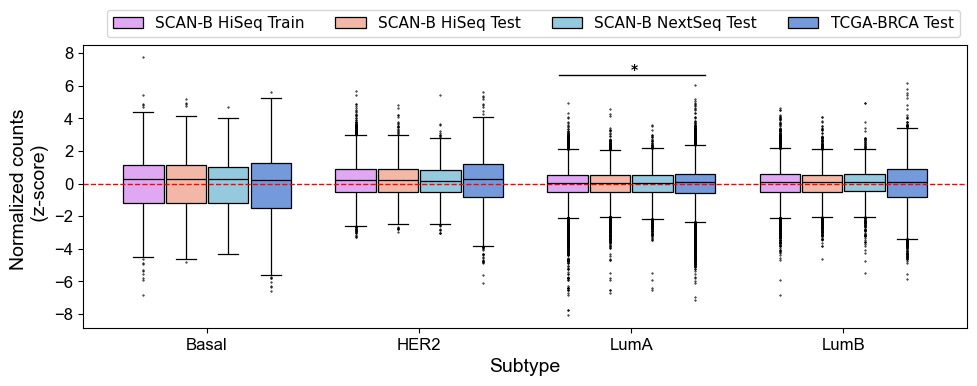

In [29]:
# plot boxplot to visualize count distribution across subtype and dataset

custom_order_subtype = ['Basal', 'HER2', 'LumA', 'LumB']
custom_palette = {'SCAN-B HiSeq Train': '#e79aff',
                  'SCAN-B HiSeq Test': '#FFB09C',
                  'SCAN-B NextSeq Test': '#87CEEB',
                  'TCGA-BRCA Test': '#6495ED'}
plt.figure(figsize=(10, 4))
sns.boxplot(x='subtype', y='std_counts', hue='dataset', data=merged_standardized_subtype_dataset_long, gap=0.05, linewidth=0.9,
           palette=custom_palette, order=custom_order_subtype, fliersize=0.5, linecolor='black', width=0.8)
# plt.title('Pooled Normalized Gene Expression Counts by Subtype and Dataset')
plt.xlabel('Subtype', fontdict={'family':'Arial','color':'black','size':14})
plt.ylabel('Normalized counts \n (z-score)', fontdict={'family':'Arial','color':'black','size':14} )
plt.legend(title='', loc='upper right', bbox_to_anchor=(1, 1.15), ncol=4, fontsize=11)
plt.xticks(rotation=0, fontsize=12, fontfamily='Arial', color='black')
plt.yticks(rotation=0, fontsize=12, fontfamily='Arial', color='black')
plt.plot([1.66, 2.35], [6.65, 6.65], color='black', linewidth=1)
plt.text(2, 6.75, '*', fontsize=10, color='black', weight='bold')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
# plt.savefig('boxplot_counts_distribution_by_subtype_dataset.png', dpi=300, bbox_inches='tight') 
plt.show()

#### 5. Visualize normalized count distribution of three genes with largest distribution shifts using boxplots
##### Genes: TYMS, MIA and MYC
##### Genes were determined based on KDE and KS-test analysis of gene-specific distribution between SCAN-B HiSeq training and TCGA-BRCA test sets

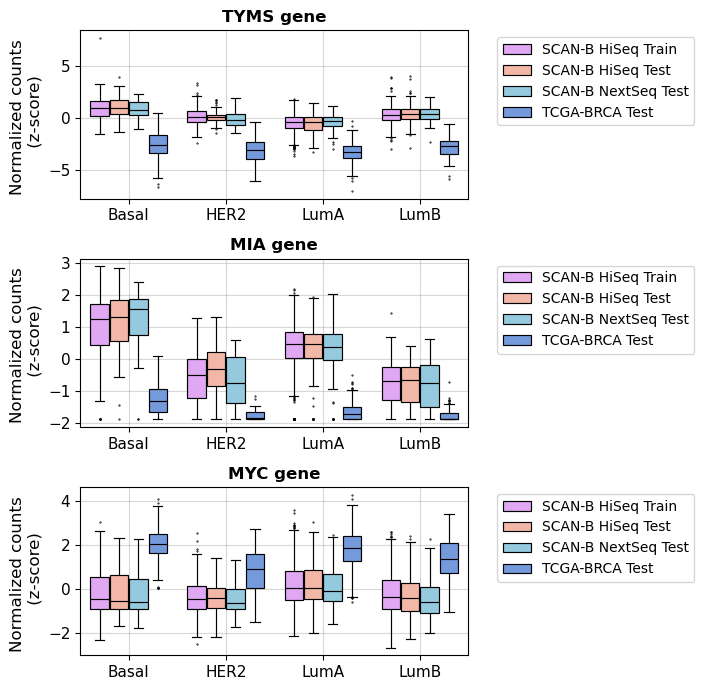

In [37]:
# plot boxplots

custom_order_subtype = ['Basal', 'HER2', 'LumA', 'LumB']
custom_palette = {'SCAN-B HiSeq Train': '#e79aff',
                  'SCAN-B HiSeq Test': '#FFB09C',
                  'SCAN-B NextSeq Test': '#87CEEB',
                  'TCGA-BRCA Test': '#6495ED'}
diff_genes = ['TYMS', 'MIA', 'MYC']
plt.figure(figsize=(9,7))
for i in range(len(diff_genes)):
    plt.subplot(3, 1, i+1)
    data = merged_standardized_subtype_dataset_long.loc[(merged_standardized_subtype_dataset_long['gene']==diff_genes[i])]
    sns.boxplot(x='subtype', y='std_counts', hue='dataset', data=data, gap=0.05, linewidth=0.85,
               palette=custom_palette, order=custom_order_subtype, fliersize=0.5, linecolor='black', width=0.8)
    plt.title(f'{diff_genes[i]} gene', fontdict={'size':12, 'color':'black', 'family':'sans-serif', 'weight': 'bold'})
    plt.xlabel('',fontsize=12, color='black', fontfamily='sans-serif')
    plt.ylabel('Normalized counts \n (z-score)', fontsize=12, color='black', fontfamily='sans-serif')
    plt.legend(title='', bbox_to_anchor=(1.6,1),loc='upper right', ncol=1, fontsize=10)
    plt.xticks(fontsize=11, color='black', fontfamily='sans-serif', rotation=0)
    plt.yticks(fontsize=11, color='black', fontfamily='sans-serif')
    plt.grid(alpha=0.5)
plt.tight_layout()
# plt.savefig('normalized_count_distribution_most_variable_genes.png', dpi=300, bbox_inches='tight')
plt.show()

#### 6. Visualize normalized count distribution of three genes with smallest distribution shifts using boxplots
##### Genes: CDC20, BAG1, FGFR4
##### Genes were determined based on KDE and KS-test analysis of gene-specific distribution between SCAN-B HiSeq training and TCGA-BRCA test sets

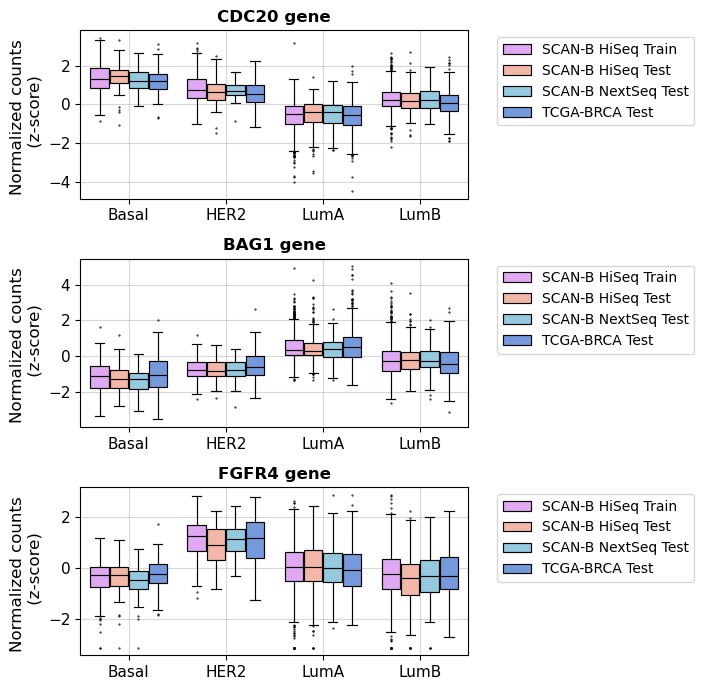

In [38]:
# plot boxplot

custom_order_subtype = ['Basal', 'HER2', 'LumA', 'LumB']
custom_palette = {'SCAN-B HiSeq Train': '#e79aff',
                  'SCAN-B HiSeq Test': '#FFB09C',
                  'SCAN-B NextSeq Test': '#87CEEB',
                  'TCGA-BRCA Test': '#6495ED'}
diff_genes = ['CDC20', 'BAG1', 'FGFR4']
plt.figure(figsize=(9,7))
for i in range(len(diff_genes)):
    plt.subplot(3, 1, i+1)
    data = merged_standardized_subtype_dataset_long.loc[(merged_standardized_subtype_dataset_long['gene']==diff_genes[i])]
    sns.boxplot(x='subtype', y='std_counts', hue='dataset', data=data, gap=0.05, linewidth=0.85,
               palette=custom_palette, order=custom_order_subtype, fliersize=0.5, linecolor='black', width=0.8)
    plt.title(f'{diff_genes[i]} gene', fontdict={'size':12, 'color':'black', 'family':'sans-serif', 'weight': 'bold'})
    plt.xlabel('',fontsize=12, color='black', fontfamily='sans-serif')
    plt.ylabel('Normalized counts \n (z-score)', fontsize=12, color='black', fontfamily='sans-serif')
    plt.legend(title='', bbox_to_anchor=(1.6,1),loc='upper right', ncol=1, fontsize=10)
    plt.xticks(fontsize=11, color='black', fontfamily='sans-serif', rotation=0)
    plt.yticks(fontsize=11, color='black', fontfamily='sans-serif')
    plt.grid(alpha=0.5)
plt.tight_layout()
# plt.savefig('normalized_count_distribution_least_variable_genes.png', dpi=300, bbox_inches='tight')
plt.show()